In [5]:
# Notebook environment setup
import sys

print("Python executable:", sys.executable)

packages = [
    "tensorflow",
    "plasmapy",
    "scikeras",
    "scikit-learn",
    "matplotlib",
    "pandas",
    "numpy",
    "scipy",
    "astropy"
]

# Upgrade pip first
!"{sys.executable}" -m pip install --upgrade pip

# Install required packages into the CURRENT notebook environment
for package in packages:
    !"{sys.executable}" -m pip install {package}

# Verify TensorFlow install
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

Python executable: c:\ml_project\Transfer Learning (Organized Final Project)\Transfer Learning.venv\Scripts\python.exe
^C
TensorFlow version: 2.21.0


## Functions

In [ ]:
def instrument_function(k):
    xpix = np.arange(len(k))
    center = len(wavelength) // 2
    sigma = 2.18
    lineshape = np.exp(-((xpix - center) ** 2) / (2 * sigma**2))
    lineshape /= np.sum(lineshape)
    return lineshape

## Plotting Experimental + Synthetic Data

In [1]:
%pip install -q --upgrade tensorflow scikeras plasmapy astropy scipy scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import pickle
from datetime import datetime

import tensorflow as tf
from astropy import units as u
from plasmapy.diagnostics import thomson
from scipy.signal import convolve
from scikeras.wrappers import KerasClassifier, KerasRegressor
from sklearn import preprocessing as pp
from sklearn.model_selection import ShuffleSplit, train_test_split, GridSearchCV

try:
    from tensorflow.keras import callbacks
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.layers import (
        InputLayer, Input, Dense, Dropout, LeakyReLU, PReLU, Reshape, Flatten,
        Conv1D, AveragePooling1D, GlobalAveragePooling1D, MaxPooling1D, UpSampling1D, Lambda
    )
    from tensorflow.keras.optimizers import Adam, SGD
    from tensorflow.keras.utils import plot_model
except ModuleNotFoundError:
    from keras import callbacks
    from keras.models import Sequential, Model
    from keras.layers import (
        InputLayer, Input, Dense, Dropout, LeakyReLU, PReLU, Reshape, Flatten,
        Conv1D, AveragePooling1D, GlobalAveragePooling1D, MaxPooling1D, UpSampling1D, Lambda
    )
    from keras.optimizers import Adam, SGD
    from keras.utils import plot_model

spectral_data = np.load('TS_spectra.npy') #
wavelengths = np.load('wavelength.npy')

temp_data = np.load('Te.npy')
dens_data = np.load('ne.npy')

#plt.interactive(True)

wavelength_flux_pairs = []

for i in range(len(spectral_data)):
    spectrum_pairs = []
    for j in range(len(wavelengths)):
        spectrum_pairs.append((wavelengths[j], spectral_data[i, j]))
    wavelength_flux_pairs.append(spectrum_pairs)

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from plasmapy.diagnostics import thomson
from scipy.signal import convolve
from astropy import units as u
import tensorflow as tf
import pickle
from sklearn.model_selection import ShuffleSplit, train_test_split
from sklearn import preprocessing as pp
from datetime import datetime
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import InputLayer, Input, Dense, Dropout, LeakyReLU, PReLU, Reshape, Flatten
from tensorflow.keras.optimizers import Adam, SGD
from datetime import datetime
from tensorflow.keras.utils import plot_model
from tensorflow.keras import callbacks


In [3]:
probe_wavelength = 532 * u.nm
T_ion = 0.1 * u.eV
temp_data_units = temp_data * u.eV
wavelenghts_units = wavelengths * u.nm
dens_data_units = dens_data * u.cm**-3
scattering_angle = 90 * u.degree
mag_probe_vec = (4 * np.pi / probe_wavelength) * np.sin(scattering_angle/2)

probe_vec = np.array([1, 0, 0]) # DEFINE ORTHOGONAL VECTORS
scatter_vec = np.array([0, 1, 0]) # THAT ALLIGN WITH 90 DEGREE SCATTERING

alphas = []
SKWs = []
for i in range(len(temp_data_units)):
    cur_alpha, cur_Skw = thomson.spectral_density(
        wavelenghts_units,
        probe_wavelength,
        dens_data_units[i],
        T_e = temp_data_units[i],
        T_i = T_ion,
        probe_vec = probe_vec,
        scatter_vec=scatter_vec
        )
    alphas.append(cur_alpha)
    SKWs.append(cur_Skw)

c:\ml_project\Transfer Learning (Organized Final Project)\Transfer Learning.venv\Lib\site-packages\plasmapy\diagnostics\thomson.py:209: RuntimeWarning: divide by zero encountered in divide
  alpha = np.sqrt(2) * wpe / np.outer(k, vT_e)
c:\ml_project\Transfer Learning (Organized Final Project)\Transfer Learning.venv\Lib\site-packages\plasmapy\diagnostics\thomson.py:212: RuntimeWarning: divide by zero encountered in divide
  xe = np.outer(1 / vT_e, 1 / k) * w_e
c:\ml_project\Transfer Learning (Organized Final Project)\Transfer Learning.venv\Lib\site-packages\plasmapy\formulary\dielectric.py:292: RuntimeWarning: divide by zero encountered in divide
  alpha = np.sqrt(2) * wp / (kWave * vth)
c:\ml_project\Transfer Learning (Organized Final Project)\Transfer Learning.venv\Lib\site-packages\plasmapy\formulary\dielectric.py:294: RuntimeWarning: divide by zero encountered in divide
  zeta = omega / (kWave * vth)
c:\ml_project\Transfer Learning (Organized Final Project)\Transfer Learning.venv\Li

In [4]:
# Data Exploration

## Spectra don't match up without Convolution

In the paper they explicitly state synthetic spectra are built as n_e S(k, w) convolved with instrument response.

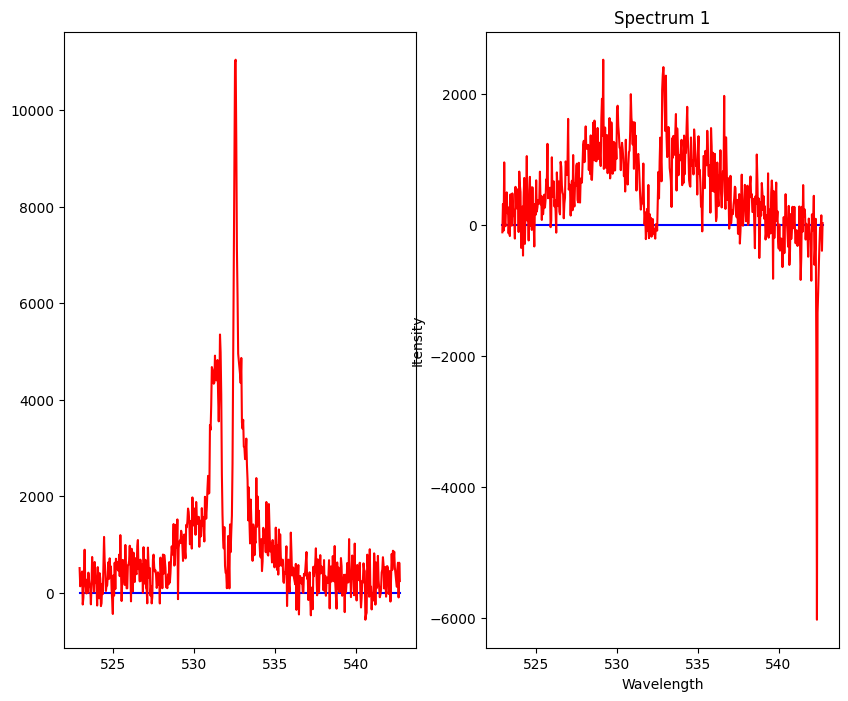

In [5]:
fig, axes = plt.subplots(1, 2, figsize = (10, 8))
ax_flat = axes.flatten()

for i in range(len(ax_flat)): 
    ax_flat[i].plot(wavelenghts_units, SKWs[i], c= 'blue')
    wavelengths_cur, intensities_cur = zip(*wavelength_flux_pairs[i])
    ax_flat[i].plot(wavelengths_cur, intensities_cur, c = 'red')
    plt.xlabel("Wavelength")
    plt.ylabel("Itensity")
    plt.title(f"Spectrum 1")


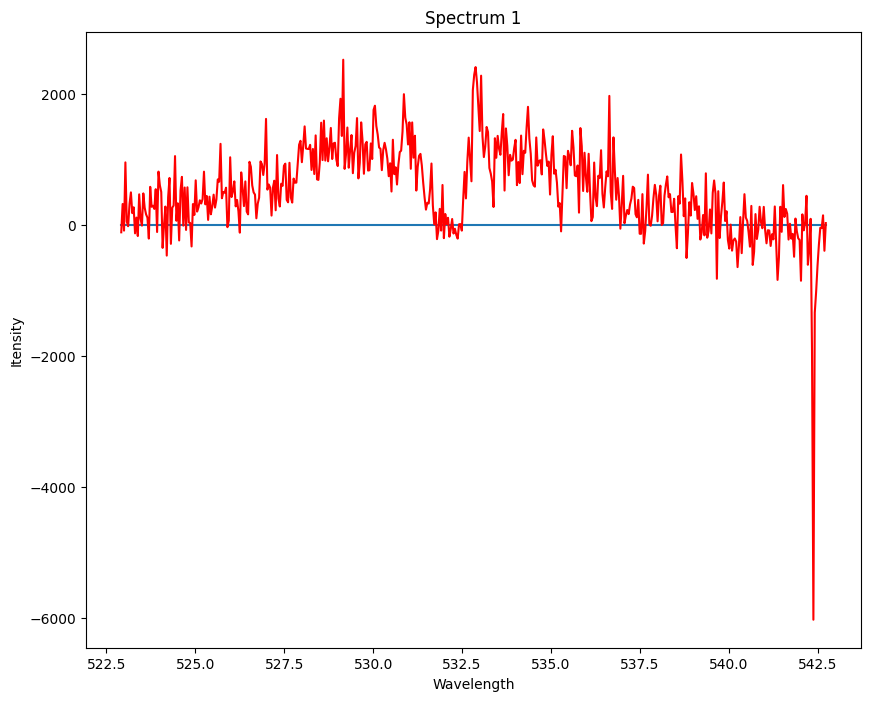

In [6]:
fig, ax = plt.subplots(1, 1, figsize = (10, 8))

ax.plot(wavelenghts_units, SKWs[1])
wavelengths_1, intensities_1 = zip(*wavelength_flux_pairs[1])
ax.plot(wavelengths_1, intensities_1, c = 'red')
plt.xlabel("Wavelength")
plt.ylabel("Itensity")
plt.title(f"Spectrum 1")
plt.show()

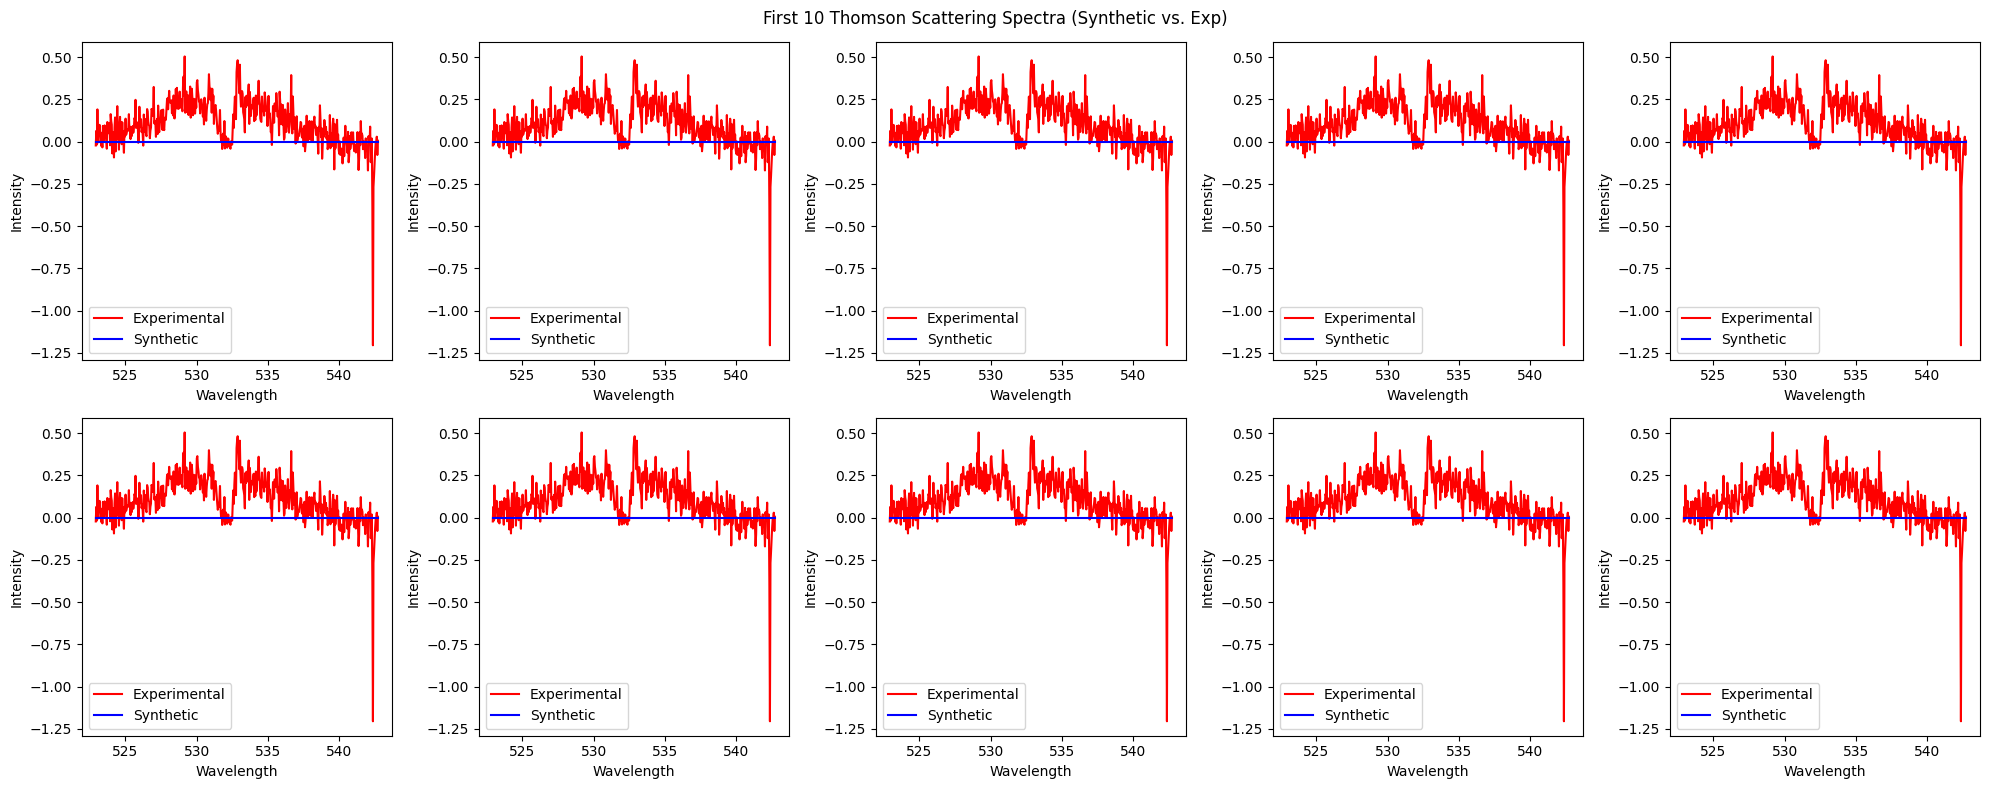

In [7]:
fig, axes = plt.subplots(2, 5, figsize = (20, 8)) #Plot first 10
ax_flat = axes.flatten()

for i, ax in zip(range(10), ax_flat):
    exp = np.array(intensities_1) #Grab Experimental Data
    syn = np.array(SKWs[i]) #Grab Synthetic Data for spectrum i
    exp_n = exp / 5000 #Normalize
    syn_n = syn / 5000 #Normalize
    ax.plot(wavelengths, exp_n, 'r', label='Experimental')
    ax.plot(wavelenghts_units.value, syn_n, 'b', label='Synthetic')
    ax.set_xlabel('Wavelength')
    ax.set_ylabel('Intensity')
    ax.legend()
plt.suptitle('First 10 Thomson Scattering Spectra (Synthetic vs. Exp)')
plt.tight_layout()

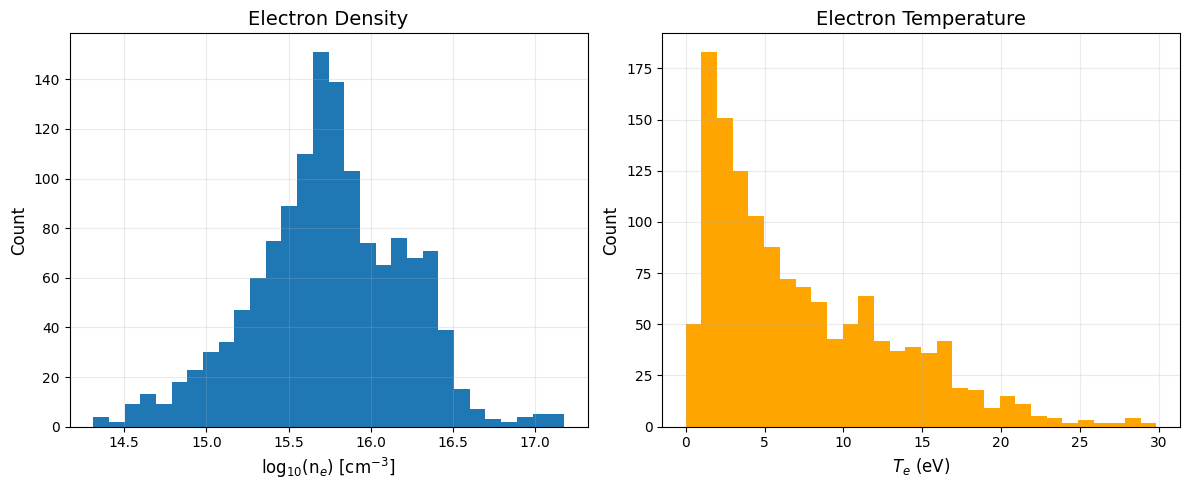

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(np.log10(dens_data), bins=30)
axes[0].set_xlabel('log$_{10}$(n$_e$) [cm$^{-3}$]', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Electron Density', fontsize=14)
axes[0].grid(alpha=0.25)

axes[1].hist(temp_data, bins=30, color='orange')
axes[1].set_xlabel('$T_e$ (eV)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Electron Temperature', fontsize=14)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

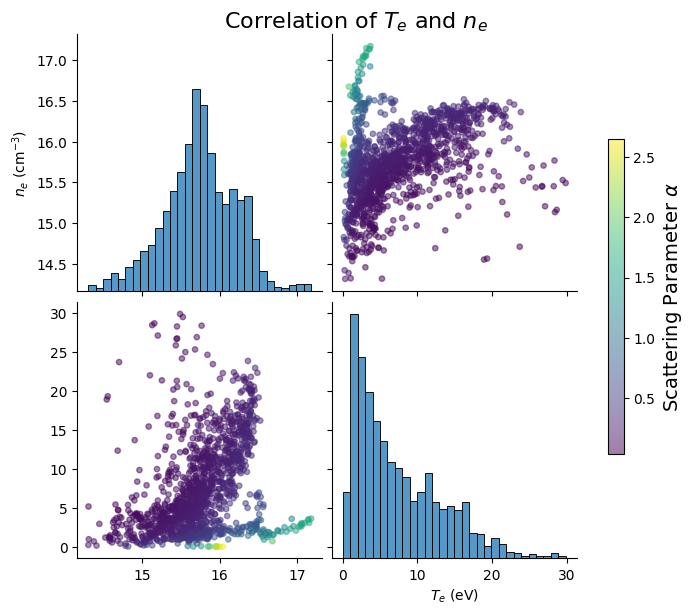

In [9]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame({
    '$n_e$ (cm$^{-3}$)': np.log10(dens_data),
    '$T_e$ (eV)': temp_data,
    '$\\alpha$': alphas
})

g = sns.pairplot(
    df,
    height=3,
    aspect=1.2,
    vars=['$n_e$ (cm$^{-3}$)', '$T_e$ (eV)'],
    plot_kws={'alpha': 0.5, 's': 15},
    diag_kws={'bins': 30},
    diag_kind='hist',
)

for i, j in [(0,1), (1,0)]:
    g.axes[i][j].cla()
    sc = g.axes[i][j].scatter(
        df.iloc[:, j],
        df.iloc[:, i],
        c=alphas,
        cmap='viridis',
        alpha=0.5,
        s=15
    )

cbar = g.fig.colorbar(sc, ax=g.axes, shrink=0.6, pad=0.05)
cbar.set_label("Scattering Parameter $\\alpha$", fontsize=14)

g.fig.suptitle("Correlation of $T_e$ and $n_e$",
               fontsize=16, y=1.02)

plt.show()

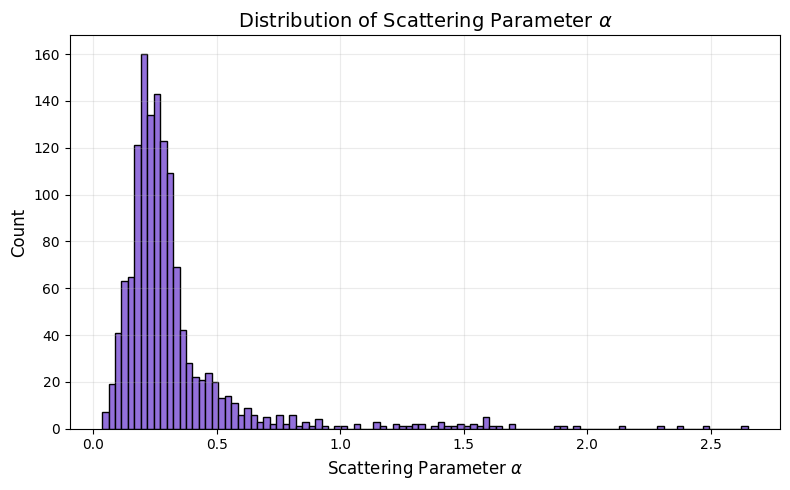

Removed 1 inf values out of 1350 total


In [10]:
alphas_clean = np.array(alphas)
alphas_clean = alphas_clean[np.isfinite(alphas_clean)]
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(alphas_clean, bins=100, color='mediumpurple', edgecolor='black')
ax.set_xlabel('Scattering Parameter $\\alpha$', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Scattering Parameter $\\alpha$', fontsize=14)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f'Removed {len(alphas) - len(alphas_clean)} inf values out of {len(alphas)} total')

# Matching Synthetic Data with Experimental

### Singular Example

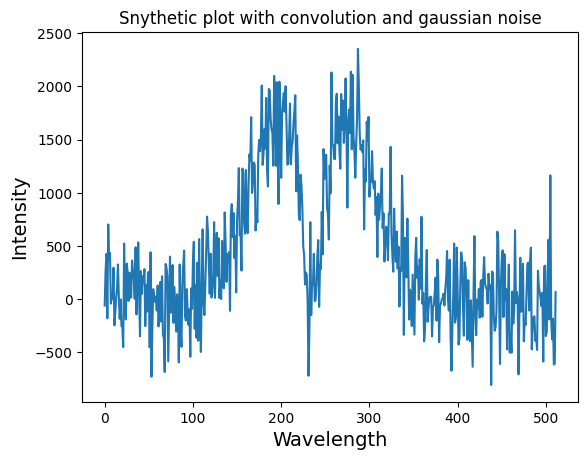

In [11]:
def instrument_function(k):
    """Function initializing gaussian with FWHM 1.2nm designed to broaden the experimental TS Spectral Plotting + Fitting.ipynb

    """
    xpix = np.arange(len(k))
    center = len(wavelengths) // 2
    sigma = 2.18
    lineshape = np.exp(-((xpix - center) ** 2)/ (2* sigma**2))
    lineshape /= np.sum(lineshape) #Normalize
    return lineshape


inst_instance = instrument_function(wavelenghts_units)
## Gaussian Notch
G = 1 - np.exp( - ((wavelengths -532)**2./(2*(0.48**2))))

SKW_scaled = G*(SKWs[0] *dens_data_units[0])

SKW_convolved_first = convolve(SKW_scaled, inst_instance, mode='same')

#plt.plot(np.linspace(0, len(SKW_convolved_first) - 1, len(SKW_convolved_first)), SKW_convolved_first)
#Scale after adding noise

## Adding Random Gaussian Noise
mean = 0
std_dev = 10 ** 2.5
noise = np.random.normal(mean, std_dev, wavelengths.size)
SKW_convolved_first += noise

plt.title('Snythetic plot with convolution and gaussian noise')
plt.ylabel('Intensity', fontsize = '14')
plt.xlabel('Wavelength', fontsize = '14')
plt.plot(np.linspace(0, len(SKW_convolved_first) - 1, len(SKW_convolved_first)), SKW_convolved_first)





### Automate
**Don't Forget to plot Pre-Instrument Function and Pre Gaussian Noise before for comparison**

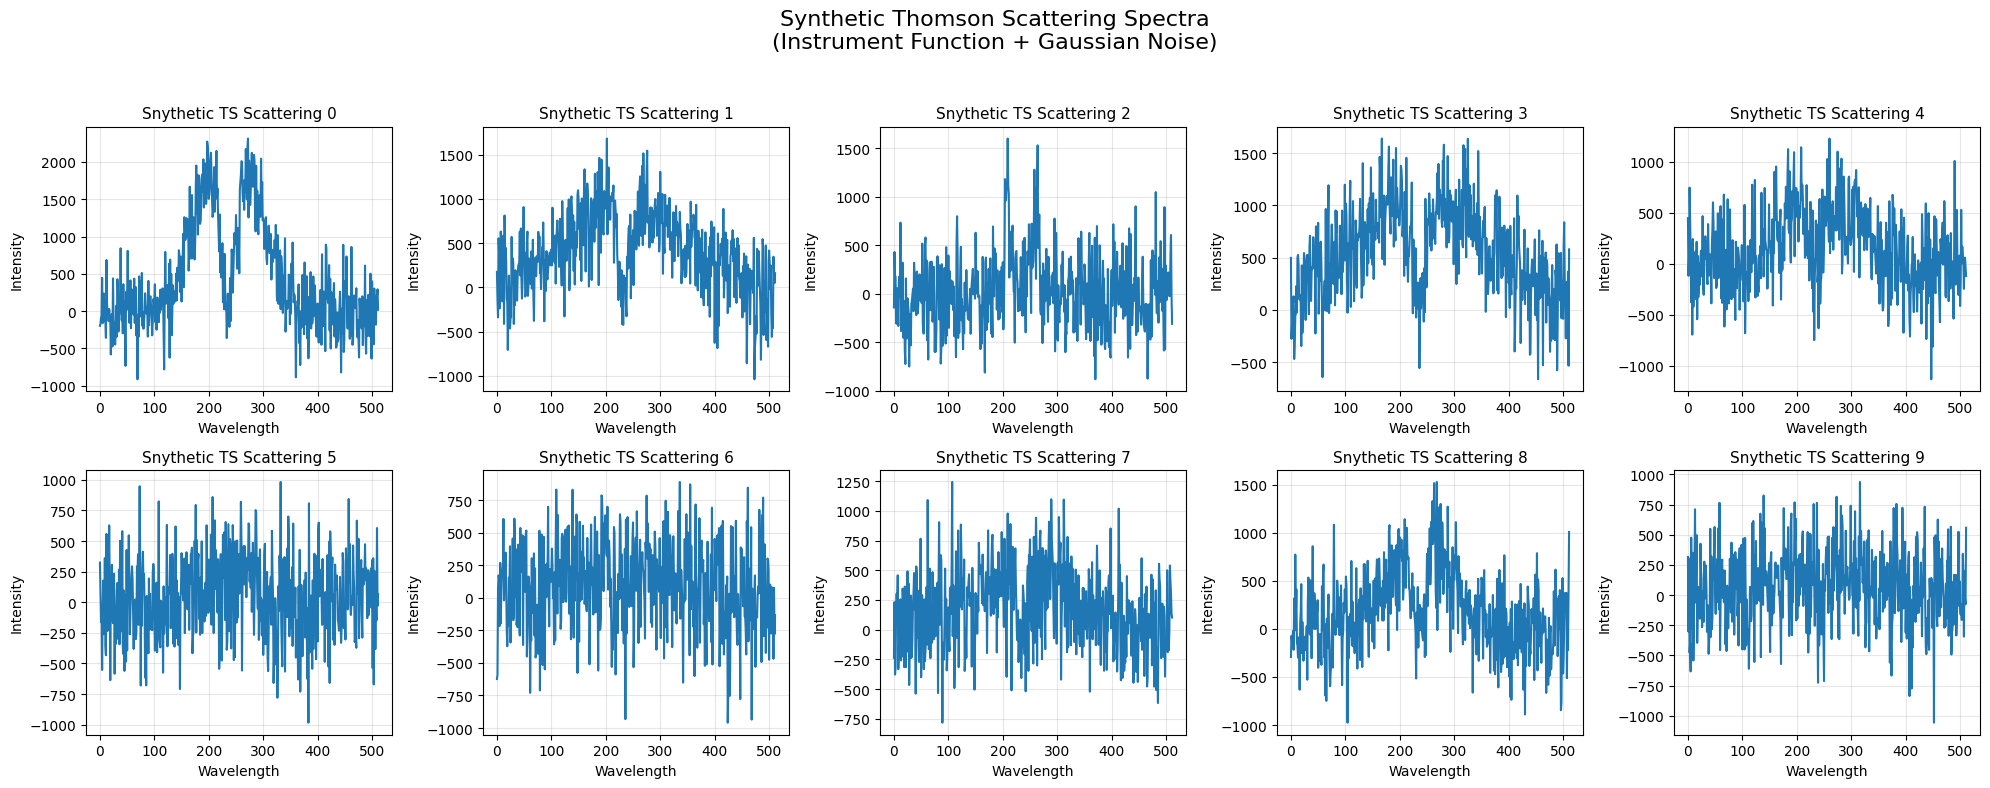

In [12]:
fig, axes = plt.subplots(2, 5, figsize = (20, 8))

ax_flat = axes.flatten()
for i in range(10):
    cur_skw = SKWs[i]
    SKW_scaled = G * (SKWs[i] * dens_data_units[i])
    SKW_convolved = convolve(SKW_scaled, inst_instance, mode = 'same')
    ## Adding Random Gaussian Noise
    mean = 0
    std_dev = 10 ** 2.5
    noise = np.random.normal(mean, std_dev, wavelengths.size)
    SKW_convolved += noise
    ax_flat[i].plot(np.linspace(0, len(SKW_convolved) - 1, len(SKW_convolved)), SKW_convolved, linewidth = 1.5)
    ax_flat[i].set_title(f'Snythetic TS Scattering {i}', fontsize = 11)
    ax_flat[i].set_xlabel('Wavelength')
    ax_flat[i].set_ylabel('Intensity')
    ax_flat[i].grid(alpha=0.3)


fig.suptitle('Synthetic Thomson Scattering Spectra\n(Instrument Function + Gaussian Noise)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

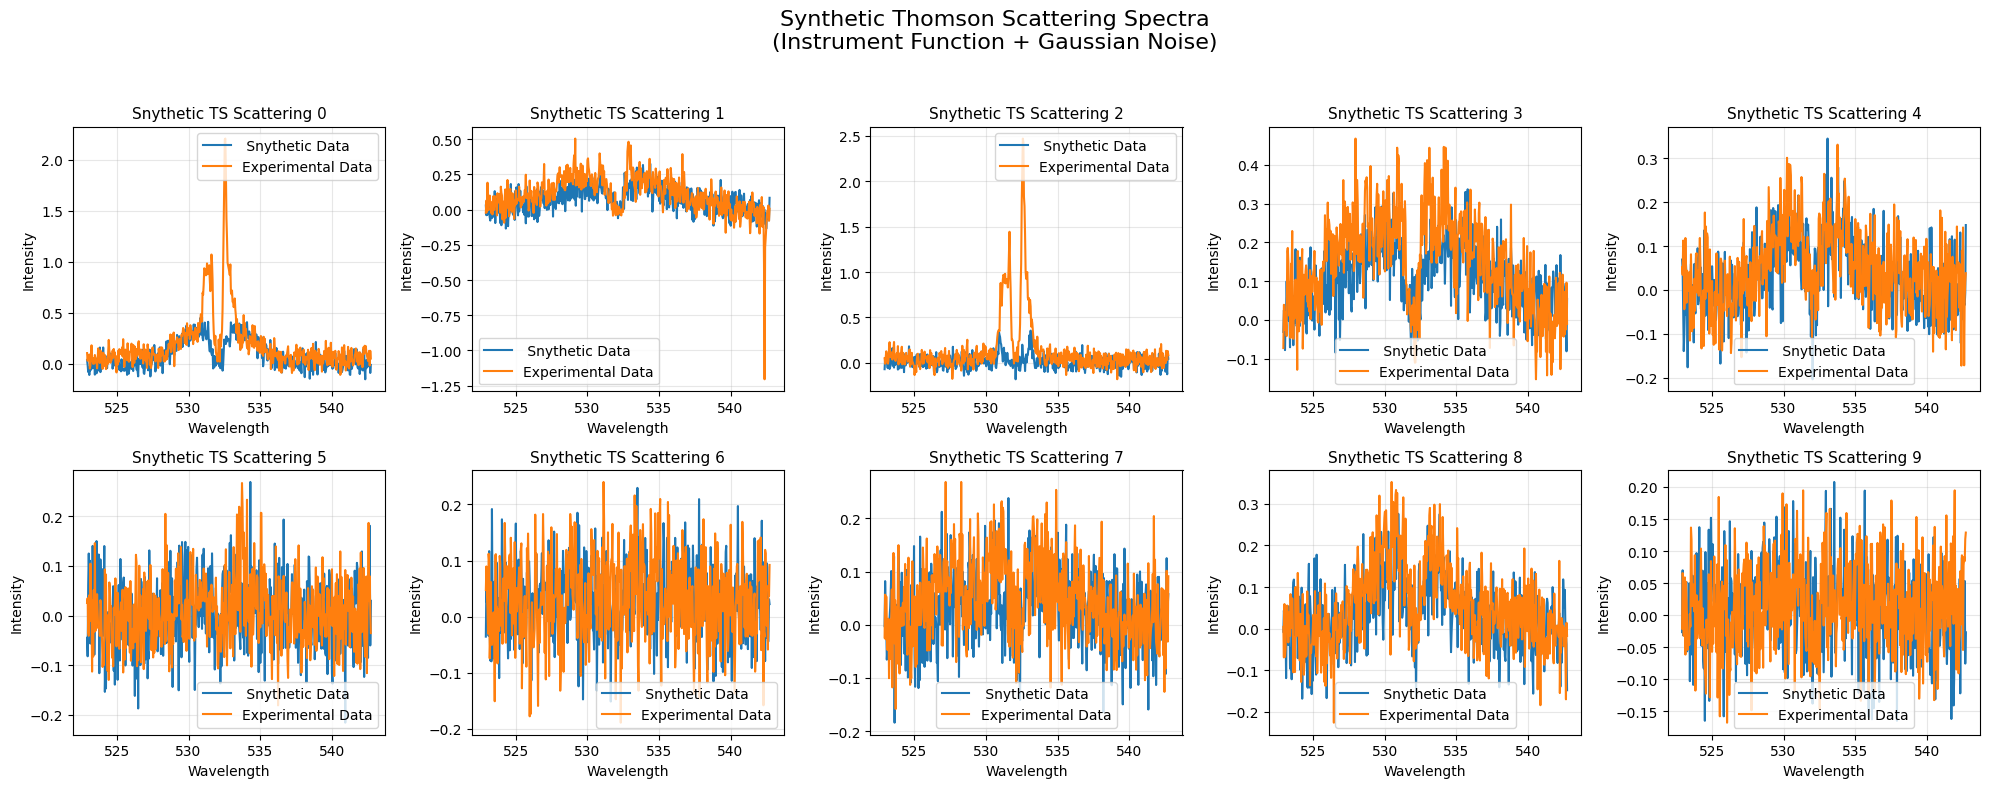

In [13]:
fig, axes = plt.subplots(2, 5, figsize = (20, 8))

ax_flat = axes.flatten()
for i in range(10):
    exp_wavelengths, exp_intensities = zip(*wavelength_flux_pairs[i])
    cur_skw = SKWs[i]
    SKW_scaled = G * (SKWs[i] * dens_data_units[i])
    SKW_convolved = convolve(SKW_scaled, inst_instance, mode = 'same')
    ## Adding Random Gaussian Noise
    mean = 0
    std_dev = 10 ** 2.5
    noise = np.random.normal(mean, std_dev, wavelengths.size)
    SKW_convolved += noise
    # Normalize before plotting
    exp_wavelengths = np.array(exp_wavelengths)
    exp_intensities = np.array(exp_intensities)
    exp_intensities /= 5000
    SKW_convolved /= 5000
    # if your synthetic grid matches exp_wavelengths length:
    ax_flat[i].plot(exp_wavelengths, SKW_convolved, linewidth=1.5, label =' Snythetic Data')
    ax_flat[i].plot(exp_wavelengths, exp_intensities, label= 'Experimental Data')
    ax_flat[i].set_title(f'Snythetic TS Scattering {i}', fontsize = 11)
    ax_flat[i].set_xlabel('Wavelength')
    ax_flat[i].set_ylabel('Intensity')
    ax_flat[i].grid(alpha=0.3)
    ax_flat[i].legend()

fig.suptitle('Synthetic Thomson Scattering Spectra\n(Instrument Function + Gaussian Noise)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

### Functions for cleaning spectra, Data Cleaning

In [14]:
#Two function
#plot_three_spectra to plot several spectra at a time on the same plot to compare them
#remove_spikes takes in a spectrum, and replaces huge spikes that are some threshold with the average of it's neighbors within a distance n.
def plot_three_spectra(spectra, wavelengths):
    n_spectra = np.arange(0,1344,4)

    for i in n_spectra:
        plt.xlabel("wavelength (nm)")
        plt.ylabel('intensity/spectra')
        for j in range(i,i+3):
            plt.plot(wavelengths, spectra[j]+1000*(i%3), label = f'spectra{j}', linewidth = 0.5)
        plt.title(f"Spectra {i}, {i+1}, {i+2}, {i+3}")
        plt.legend()
        plt.show()


def remove_spikes(wavelengths, spectrum, threshold, protected_center=np.arange(203,300,1),):
    n=3 #radius of bins to compare to
    x = np.asarray(wavelengths, dtype=float)
    y = np.asarray(spectrum, dtype=float)
    y_clean = y.copy()
    replaced = np.zeros(len(y), dtype=bool)

    for i in range(len(y)):

        lo = max(0, i - n) #i-th bin - n to it's left
        hi = min(len(y), i + n + 1) #ith bin + n to its right
        neighbours = np.concatenate([y[lo:i], y[i+1:hi]]) #list containing neighbors surrounding #ith bin

        if len(neighbours) == 0:
            continue

        local_mean = np.mean(neighbours)

        if abs(y[i]) - abs(local_mean) > threshold: #removes minima or spikes that are way above local mean
            y_clean[i] = local_mean
            replaced[i] = True

    return y_clean

n, bins = spectral_data.shape
spikeless_spectra = []

for i in range(0,n):
    spikeless_spectra.append(remove_spikes(wavelengths, spectral_data[i], 3000))
spikeless_spectra = np.array(spikeless_spectra)



### Save Spectral Data

In [15]:
import h5py

In [16]:
import math
syn_spectra = []

for i in range(len(SKWs)):
    exp_wavelengths, exp_intensities = zip(*wavelength_flux_pairs[i])
    exp_wavelengths = np.array(exp_wavelengths)
    exp_intensities = np.array(exp_intensities, dtype=float)
    cur_skw = SKWs[i]
    SKW_scaled = G * (SKWs[i] * dens_data_units[i])
    SKW_convolved = convolve(SKW_scaled, inst_instance, mode = 'same')
    ## Adding Random Gaussian Noise
    mean = 0
    std_dev = 10 ** 2.5
    noise = np.random.normal(mean, std_dev, wavelengths.size)
    SKW_convolved += noise
    # Normalize before plotting
    exp_intensities /= 5000
    SKW_convolved /= 5000
    syn_spectra.append(SKW_convolved)


syn_spectra

ion_temp = np.full(len(SKWs), 0.1)

with h5py.File('synthetic_spectra.h5', 'w') as f:
    f.create_dataset('spectra', data = syn_spectra)
    f.create_dataset('wavelengths', data = wavelenghts_units)
    f.create_dataset('alphas', data = alphas)
    f.create_dataset('ion_temperature', data = ion_temp)
    print("Saved Successfully")

fig.suptitle('Synthetic Thomson Scattering Spectra\n(Instrument Function + Gaussian Noise)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

Saved Successfully


<Figure size 640x480 with 0 Axes>

### Reading it back in

In [17]:
with h5py.File('synthetic_spectra.h5', 'r') as f:
    loaded_spectra = f['spectra'][:]
    loaded_wavelengths = f['wavelengths'][:]
    loaded_alphas = f['alphas'][:]
    loaded_ions = f['ion_temperature'][:]
    print("Loaded Successfully")

Loaded Successfully


### Save the Experimental Data

In [18]:


with h5py.File('experimental_spectra.h5', 'w') as f:
    f.create_dataset('spectra', data = spectral_data)
    f.create_dataset('wavelengths', data = wavelengths)
    f.create_dataset('electron_density', data = dens_data)
    f.create_dataset('electron_temperature', data = temp_data)
    f.create_dataset('ion temperature', data = ion_temp)
    print('Saved Successfully')

Saved Successfully


### Reading in the Experimental Data

In [19]:
with h5py.File('experimental_spectra.h5', 'r') as f:
    exp_spectra = f['spectra'][:]
    exp_wavelengths = f['wavelengths'][:]
    exp_densities = f['electron_density'][:]
    exp_temperatures = f['electron_temperature'][:]
    print('Loaded Successfully')

Loaded Successfully


### Distribution of Experimental Temperature vs. Density data (synthetic vs. experimental alphas)
From the plots, we can see that the alphas for the different observations are encoded roughly the same, suggesting that the estimated regimes (given by the salpeter parameter **α** of the snythetic and experimental data) for the same temperature and densities are roughly the same for the different spectra.  

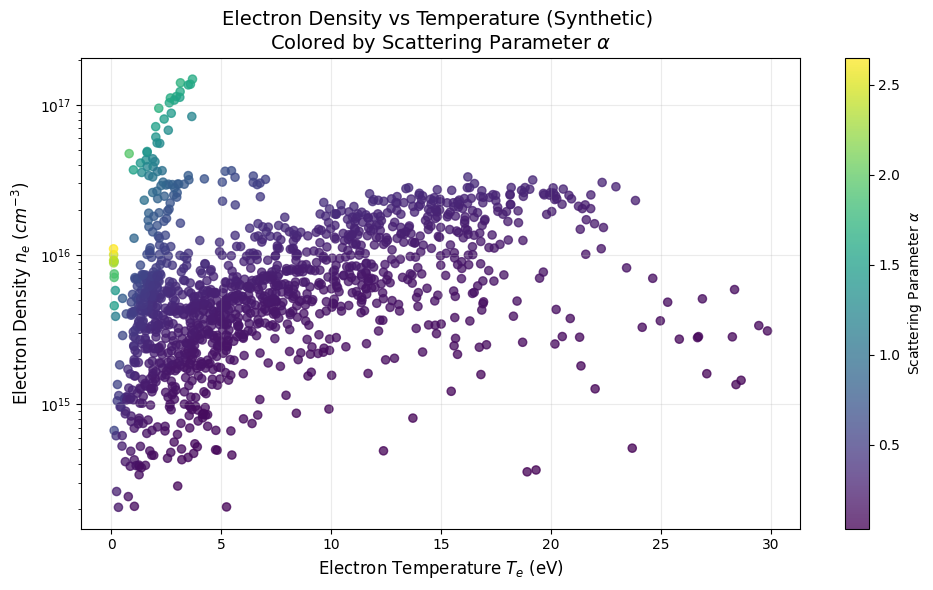

In [20]:
plt.figure(figsize=(10,6))

sc = plt.scatter(
    temp_data,
    dens_data,
    c=alphas,
    cmap='viridis',
    s=35,
    alpha=0.75
)

plt.yscale('log')

plt.xlabel("Electron Temperature $T_e$ (eV)", fontsize=12)
plt.ylabel("Electron Density $n_e$ ($cm^{-3}$)", fontsize=12)
plt.title("Electron Density vs Temperature (Synthetic) \nColored by Scattering Parameter $\\alpha$", fontsize=14)

cbar = plt.colorbar(sc)
cbar.set_label("Scattering Parameter $\\alpha$")

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

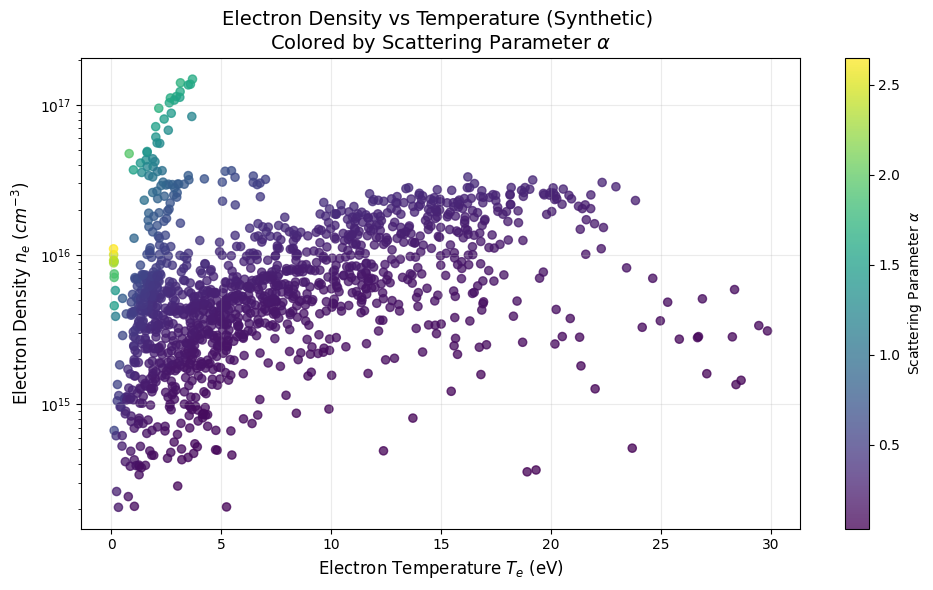

In [21]:
plt.figure(figsize=(10,6))

sc = plt.scatter(
    temp_data,
    dens_data,
    c=loaded_alphas,
    cmap='viridis',
    s=35,
    alpha=0.75
)

plt.yscale('log')

plt.xlabel("Electron Temperature $T_e$ (eV)", fontsize=12)
plt.ylabel("Electron Density $n_e$ ($cm^{-3}$)", fontsize=12)
plt.title("Electron Density vs Temperature (Synthetic) \nColored by Scattering Parameter $\\alpha$", fontsize=14)

cbar = plt.colorbar(sc)
cbar.set_label("Scattering Parameter $\\alpha$")

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Neural Network trained on the **snythetic** data alone

---



In [22]:
X = loaded_spectra
Y = np.column_stack((exp_densities, exp_temperatures, loaded_alphas, loaded_ions))

In [23]:
Xi = X[0]
Yi = Y[0]
mis = Xi.shape # Inputshape (currently total # of samples in dataset)
mos = Yi.size #Output shape



In [24]:
model = Sequential()
model.add(Input(shape=mis))
model.add(Dense(512,activation='relu'))
model.add(Dense(256,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(mos, activation='linear'))

model.summary()

###### STUDY THIS ##########################################
# callbacks (stop training when it isn't improving further)
es = callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=5,
    verbose=2,
    mode="min",
    restore_best_weights=True,
)

lr = 0.001
optimizer = Adam(learning_rate=lr)
model.compile(optimizer=optimizer, loss="mse", metrics=['accuracy'])



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,396 (1.66 MB)

 Trainable params: 435,396 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# scale the data using sklearn preprocessing
import pickle as pkl
X = np.asarray(X, dtype=np.float64)
Y = np.asarray(Y, dtype=np.float64)
t_scaler = pp.StandardScaler()
x_scaler = pp.MinMaxScaler()
X = x_scaler.fit_transform(X)
y_scaler = pp.MinMaxScaler()
# Clean non-finite rows before scaling targets
X = np.asarray(X, dtype=np.float64)
Y = np.asarray(Y, dtype=np.float64)

## Remove invalid rows
valid_rows = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
if not np.all(valid_rows):
    print(f"Removing {np.size(valid_rows) - np.count_nonzero(valid_rows)} rows with NaN/Inf values")
    X = X[valid_rows]
    Y = Y[valid_rows]

Y = y_scaler.fit_transform(Y)

X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(X, Y, train_size = 0.75, shuffle=True, random_state=11)


print('total number of training samples is %1.f'%(y_train_syn[:,0].size))

Removing 1 rows with NaN/Inf values
total number of training samples is 1011


### Fitting the Model

**GRID SEARCH FOR SYNTHETIC DATA**


In [26]:
def new_func():
    def build_model(learning_rate=0.0001):
        model2 = Sequential()
        model2.add(Input(shape=mis))
        model2.add(Dense(512, activation='relu'))
        model2.add(Dense(256, activation='relu'))
        model2.add(Dense(128, activation='relu'))
        model2.add(Dense(64,  activation='relu'))
        model2.add(Dense(mos, activation='linear'))
        model2.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['accuracy'])
        return model2

    early_stop = globals().get(
        "es",
        callbacks.EarlyStopping(
            monitor="val_loss",
            min_delta=0.0001,
            patience=5,
            verbose=2,
            mode="min",
            restore_best_weights=True,
        ),
    )

    wrapped_model = KerasRegressor(
        model=build_model,
        callbacks=[early_stop],
        validation_split=0.1,
        verbose=0
    )
    param_grid = {
        'model__learning_rate': [0.0001, 0.001, 0.01],
        'batch_size':           [64, 128],
        'epochs':               [1000]
    }
    grid = GridSearchCV(
        estimator=wrapped_model,
        param_grid=param_grid,
        cv=3,
        scoring='neg_mean_squared_error',
        verbose=2
    )

    grid.fit(X_train_syn, y_train_syn)
    print("Best params:", grid.best_params_)
    print("Best MSE:   ", -grid.best_score_)

new_func()

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 30.
[CV] END batch_size=64, epochs=1000, model__learning_rate=0.0001; total time=   4.8s
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 20.
[CV] END batch_size=64, epochs=1000, model__learning_rate=0.0001; total time=   3.5s
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 25.
[CV] END batch_size=64, epochs=1000, model__learning_rate=0.0001; total time=   3.9s
Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 18.
[CV] END batch_size=64, epochs=1000, model__learning_rate=0.001; total time=   3.1s
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 14.
[CV] END batch_size=64, epochs=1000, model__learning_rate=0.001; total time=   2.5s
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 23.
[CV] EN

In [27]:
mbs = 64# batch size
nepochs = 1000 # number of epochs
lr = 10 ** -3
history = model.fit(X_train_syn, y_train_syn, verbose=0, batch_size=mbs, epochs=nepochs, validation_split=0.1, callbacks=[es])

# save the model
savename = 'synthnoise_save.h5'
model.save(savename, overwrite=True, save_format='h5')
# save the training history
save_hist = np.vstack([history.history['loss'], history.history['accuracy']]).T
np.savetxt('save_history_%1.f.csv'%(nepochs), save_hist, delimiter=',')

#%%
plt.rcParams.update({'font.size': 10})

Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 12.


### Testing the Model

In [28]:
score = model.evaluate(X_train_syn, y_train_syn)
print("Training Set: loss=%s, accuracy=%.2f%%" % (score[0], score[1]*100))
# train_score_save.append(score)


score = model.evaluate(X_test_syn, y_test_syn, verbose=2)
print("Test Set: loss=%s, accuracy=%.2f%%" % (score[0], score[1]*100))
# train_score_save.append(score)

y_pred_syn = model.predict(X_test_syn)
mae_syn = np.mean(np.abs(y_test_syn - y_pred_syn))
print(f"MAE (scaled targets): {mae_syn:.6f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9120 - loss: 0.0029 
Training Set: loss=0.0029215647373348475, accuracy=91.20%
11/11 - 0s - 4ms/step - accuracy: 0.8817 - loss: 0.0053
Test Set: loss=0.00529725756496191, accuracy=88.17%
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
MAE (scaled targets): 0.032401


### Diagnostic Plots

#### Learning Curve

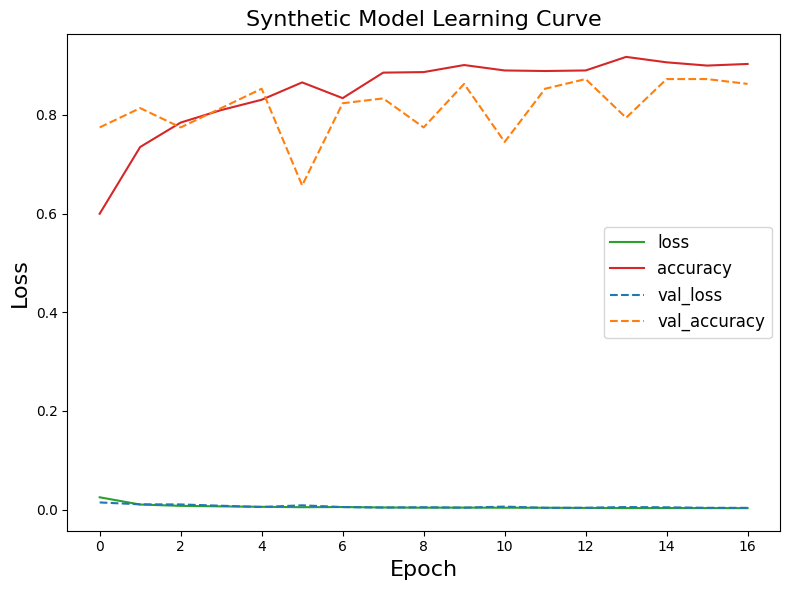

In [29]:
loss, acc = history.history['loss'], history.history['accuracy']
val_loss, val_acc = history.history['val_loss'], history.history['val_accuracy']
plt.figure(22, figsize=(8,6))
plt.clf()
plt.plot(loss, label='loss', color = 'C2')
plt.plot(acc, label='accuracy', color ='C3')
plt.plot(val_loss, ls='--', label='val_loss', color = 'C0')
plt.plot(val_acc, ls='--', label='val_accuracy', color ='C1')
# plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch', fontsize = 16)
plt.ylabel('Loss', fontsize = 16)
plt.legend(fontsize=12)
plt.title('Synthetic Model Learning Curve', fontsize = 16)
plt.tight_layout()
plt.savefig('model_latest_loss_curve.png')



In [30]:
##Synthetic+transfer+experimental

#### Real vs. Predicted Electron Densities and Temperatures

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


(np.float64(-3.179797997226128),
 np.float64(31.018359574820582),
 np.float64(-1.366687446784499),
 np.float64(32.831470125262214))

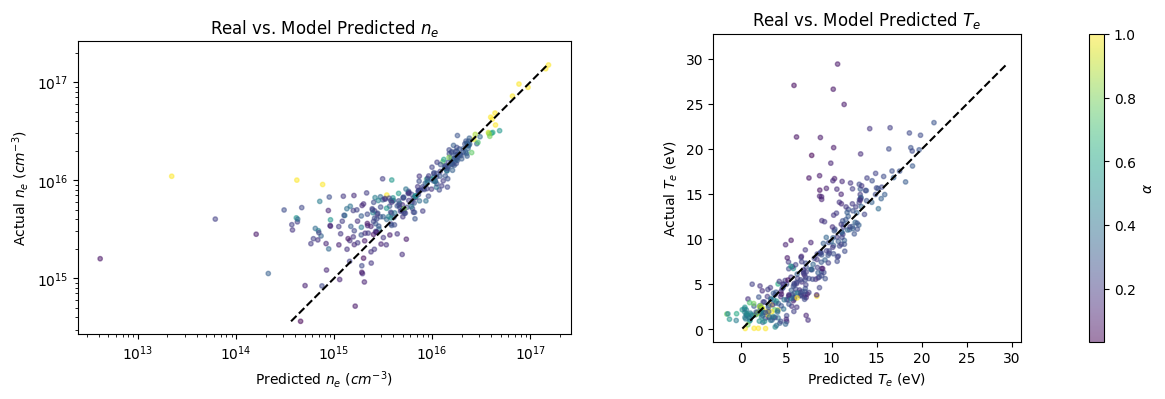

In [31]:
## Min max of the data are different from the paper, hence the different plots

predicted_scaled = model.predict(X_test_syn)
predict = y_scaler.inverse_transform(predicted_scaled) # unscale predictions to unpack value
truth = y_scaler.inverse_transform(y_test_syn)


color = np.clip(truth[:,2], 0, 1)

import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.clf()
plt.subplot(121)
plt.xscale("log")
plt.yscale("log")
plt.scatter(predict[:,0], truth[:,0], c=color, cmap='viridis', alpha=0.5, s=10)
plt.plot([truth[:,0].min(), truth[:,0].max()],
         [truth[:,0].min(), truth[:,0].max()], ls='--', c='k')
plt.xlabel('Predicted $n_e$ ($cm^{-3}$)')
plt.ylabel('Actual $n_e$ ($cm^{-3}$)')
plt.title('Real vs. Model Predicted $n_e$')
#plt.legend()
plt.axis('square')

plt.subplot(122)
sc2 = plt.scatter(predict[:,1],truth[:,1],c=color,cmap='viridis', alpha=0.5, s = 10)
plt.plot([truth[:,1].min(),truth[:,1].max()],[truth[:,1].min(),truth[:,1].max()], ls='--', c='k', label='calibration')
plt.xlabel('Predicted $T_e$ (eV)')
plt.ylabel('Actual $T_e$ (eV)')
plt.title('Real vs. Model Predicted $T_e$')
#plt.legend()
cbar = plt.colorbar(sc2)
cbar.set_label(r'$\alpha$')

plt.axis('square')


####

## Neural Network trained on the **experimental** data alone


In [34]:
# scale the data using sklearn preprocessing
import pickle as pkl
X = np.asarray(X, dtype=np.float64)
t_scaler = pp.StandardScaler()
Y = np.asarray(Y, dtype=np.float64)
x_scaler = pp.MinMaxScaler()
X = x_scaler.fit_transform(X)
y_scaler = pp.MinMaxScaler()
# Clean non-finite rows before scaling targets
X = np.asarray(X, dtype=np.float64)
Y = np.asarray(Y, dtype=np.float64)

## Remove invalid rows
valid_rows = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
if not np.all(valid_rows):
    print(f"Removing {np.size(valid_rows) - np.count_nonzero(valid_rows)} rows with NaN/Inf values")
    X = X[valid_rows]
    Y = Y[valid_rows]

Y = y_scaler.fit_transform(Y)

X_train, X_test, y_train, y_test = train_test_split(X, Y, train_size = 0.75, shuffle=True, random_state=11)


print('total number of training samples is %1.f'%(y_train[:,0].size))

filename = 'Synthnoise-InputScaler.pkl'
pkl.dump(x_scaler, open(filename, 'wb'))

total number of training samples is 1011


In [35]:
X_exp = exp_spectra
# In the paper, the only outputs were electron temperature and density

Y_exp = np.column_stack((exp_densities, exp_temperatures, alphas, loaded_ions))


Xi = X_exp[0]
Yi = Y_exp[0]
mis = Xi.shape # Inputshape (currently total # of samples in dataset)
mos = Yi.size



In [36]:
# scale the data using sklearn preprocessing
import pickle as pkl
X_exp = np.asarray(X_exp, dtype=np.float64)
Y_exp = np.asarray(Y_exp, dtype=np.float64)
t_scaler = pp.StandardScaler()
x_scaler = pp.MinMaxScaler()
X_exp = x_scaler.fit_transform(X_exp)
y_scaler = pp.MinMaxScaler()
# Clean non-finite rows before scaling targets
X_exp = np.asarray(X_exp, dtype=np.float64)
Y_exp = np.asarray(Y_exp, dtype=np.float64)

## Remove invalid rows
valid_rows = np.isfinite(X_exp).all(axis=1) & np.isfinite(Y_exp).all(axis=1)
if not np.all(valid_rows):
    print(f"Removing {np.size(valid_rows) - np.count_nonzero(valid_rows)} rows with NaN/Inf values")
    X_exp = X_exp[valid_rows]
    Y_exp = Y_exp[valid_rows]

Y_exp = y_scaler.fit_transform(Y_exp)

X_train, X_test, y_train, y_test = train_test_split(X_exp, Y_exp, train_size = 0.75, shuffle=True, random_state=11)


print('total number of training samples is %1.f'%(y_train[:,0].size))
print('total number of testing samples is %1.f'%(y_test[:,0].size))


Removing 1 rows with NaN/Inf values
total number of training samples is 1011
total number of testing samples is 338


**GRID SEARCH FOR EXPERIMENTAL**

In [37]:
def build_model2(learning_rate=0.0001):
    exp_model = Sequential()
    exp_model.add(Input(shape=mis))
    exp_model.add(Dense(512, activation='relu'))
    exp_model.add(Dense(256, activation='relu'))
    exp_model.add(Dense(128, activation='relu'))
    exp_model.add(Dense(64,  activation='relu'))
    exp_model.add(Dense(mos, activation='linear'))
    exp_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['accuracy'])
    return exp_model
wrapped_model = KerasRegressor(model=build_model2, callbacks=[es], validation_split=0.1, verbose=0)
param_grid = {
    'model__learning_rate': [0.0001, 0.001],
    'batch_size':           [128],
    'epochs':               [1000] #1000 bc the callback always stops earlier, impliticitely finding optimal epochs
}

grid = GridSearchCV(estimator=wrapped_model, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', verbose=2)

grid.fit(X_train_syn, y_train_syn)
print("Best params:", grid.best_params_)
print("Best MSE:   ", -grid.best_score_)

c:\ml_project\Transfer Learning (Organized Final Project)\Transfer Learning.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Fitting 3 folds for each of 2 candidates, totalling 6 fits
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
[CV] END batch_size=128, epochs=1000, model__learning_rate=0.0001; total time=   1.3s
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
[CV] END batch_size=128, epochs=1000, model__learning_rate=0.0001; total time=   1.2s
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
[CV] END batch_size=128, epochs=1000, model__learning_rate=0.0001; total time=   1.8s
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
[CV] END batch_size=128, epochs=1000, model__learning_rate=0.001; total time=   1.2s
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
[CV] END batch_size=128, epochs=1000, model__learning_rate=0.001; total time=   1.2s
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
[CV] END batch_

In [38]:
emodel = Sequential()
emodel.add(Input(shape=mis))
emodel.add(Dense(512,activation='relu'))
emodel.add(Dense(256,activation='relu'))
emodel.add(Dense(128,activation='relu'))
emodel.add(Dense(64,activation='relu'))
emodel.add(Dense(mos, activation='linear'))

emodel.summary()


es = callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=5,
    verbose=2,
    mode="min",
    restore_best_weights=True,
)

emodel.compile(optimizer=optimizer, loss="mse", metrics=['accuracy'])


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_135 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_136 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_137 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_138 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_139 (Dense)               │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,396 (1.66 MB)

 Trainable params: 435,396 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
### Add the experimental train, test data
lr = 0.001
emodel.compile(
    optimizer=Adam(learning_rate=lr),
    loss='mse',
    metrics=['accuracy']
)
ehistory = emodel.fit(X_train, y_train, verbose=1, batch_size=mbs, epochs=nepochs, validation_split=0.1, callbacks=[es])

# save the model
esavename = 'exp_model_save.h5'
emodel.save(esavename, overwrite=True, save_format='h5')
# save the training history
esave_hist = np.vstack([ehistory.history['loss'], ehistory.history['accuracy']]).T
np.savetxt('esave_history_%1.f.csv'%(nepochs), esave_hist, delimiter=',')


Epoch 1/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6535 - loss: 0.0180 - val_accuracy: 0.5882 - val_loss: 0.0130
Epoch 2/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7481 - loss: 0.0093 - val_accuracy: 0.7843 - val_loss: 0.0092
Epoch 3/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7987 - loss: 0.0081 - val_accuracy: 0.7843 - val_loss: 0.0084
Epoch 4/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8086 - loss: 0.0068 - val_accuracy: 0.7941 - val_loss: 0.0073
Epoch 5/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7932 - loss: 0.0078 - val_accuracy: 0.8039 - val_loss: 0.0066
Epoch 6/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8086 - loss: 0.0075 - val_accuracy: 0.8039 - val_loss: 0.0075
Epoch 7/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8251 - loss: 0.0060 - val_accuracy: 0.8039 - val_loss: 0.0055
Epoch 8/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8372 - loss: 0.0056 - val_accuracy: 0

#### Test the model

In [40]:
score = emodel.evaluate(X_train, y_train)
print("Training Set: loss=%s, accuracy=%.2f%%" % (score[0], score[1]*100))
# train_score_save.append(score)


score = emodel.evaluate(X_test, y_test, verbose=2)
print("Test Set: loss=%s, accuracy=%.2f%%" % (score[0], score[1]*100))
# train_score_save.append(score)

y_pred_exp = emodel.predict(X_test)
mae_exp = np.mean(np.abs(y_test - y_pred_exp))
print(f"MAE (scaled targets): {mae_exp:.6f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8882 - loss: 0.0020 
Training Set: loss=0.0020161254797130823, accuracy=88.82%
11/11 - 0s - 4ms/step - accuracy: 0.8846 - loss: 0.0042
Test Set: loss=0.004153321962803602, accuracy=88.46%
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
MAE (scaled targets): 0.029957


## Training Plots

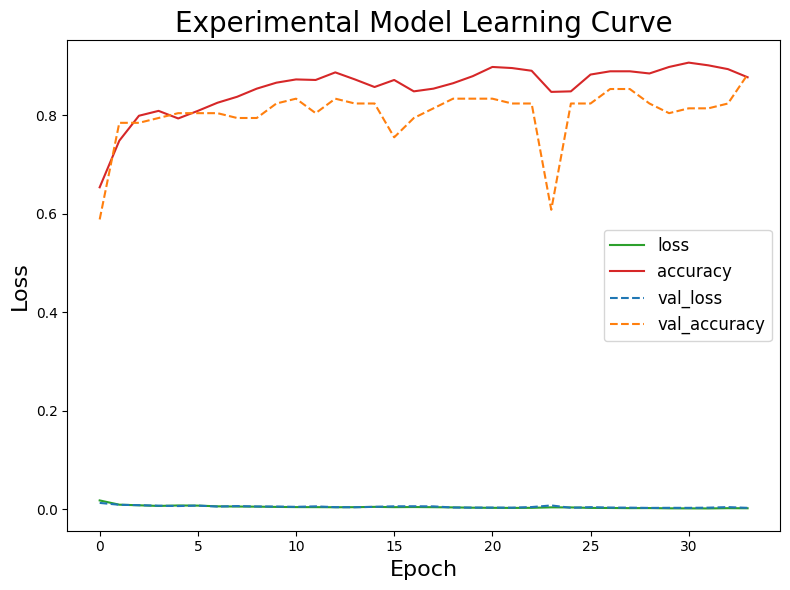

In [41]:
loss, acc = ehistory.history['loss'], ehistory.history['accuracy']
val_loss, val_acc = ehistory.history['val_loss'], ehistory.history['val_accuracy']
plt.figure(22, figsize=(8,6))
plt.clf()
plt.plot(loss, label='loss', color = 'C2')
plt.plot(acc, label='accuracy', color ='C3')
plt.plot(val_loss, ls='--', label='val_loss', color = 'C0')
plt.plot(val_acc, ls='--', label='val_accuracy', color ='C1')
# plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch', fontsize = 16)
plt.ylabel('Loss', fontsize = 16)
plt.title('Experimental Model Learning Curve', fontsize = 20)

plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('model_latest_loss_curve.png')



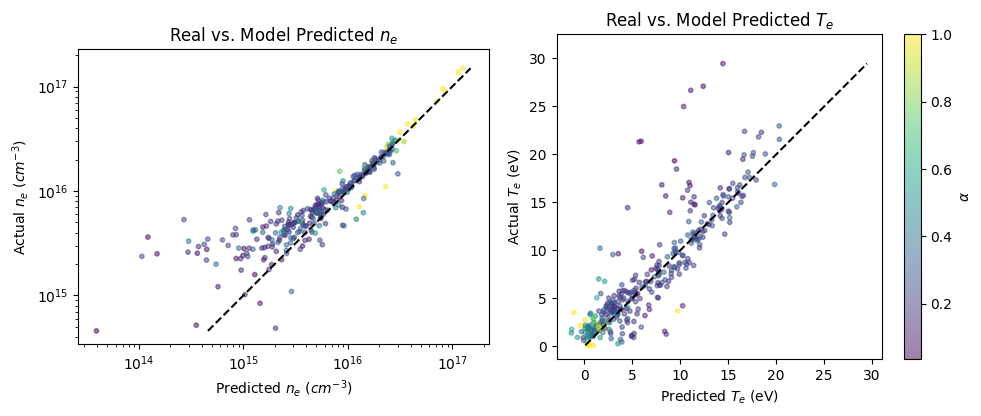

In [42]:
# Predictions (already-scaled -> back to physical units)
predicted_scaled = emodel.predict(X_test, verbose=0)
predict = y_scaler.inverse_transform(predicted_scaled)
truth = y_scaler.inverse_transform(y_test)

# alpha is the 3rd target in this model (n_e, T_e, alpha)
color = np.clip(truth[:, 2], 0, 1)

# Guard log plot against non-positive values
ne_pred = predict[:, 0]
ne_true = truth[:, 0]
mask_ne = np.isfinite(ne_pred) & np.isfinite(ne_true) & (ne_pred > 0) & (ne_true > 0)

te_pred = predict[:, 1]
te_true = truth[:, 1]
mask_te = np.isfinite(te_pred) & np.isfinite(te_true)

plt.figure(figsize=(10, 4))
plt.clf()

# Density plot
plt.subplot(121)
plt.xscale("log")
plt.yscale("log")
plt.scatter(ne_pred[mask_ne], ne_true[mask_ne], c=color[mask_ne], cmap="viridis", alpha=0.5, s=10)
mn, mx = ne_true[mask_ne].min(), ne_true[mask_ne].max()
plt.plot([mn, mx], [mn, mx], ls="--", c="k")
plt.xlabel("Predicted $n_e$ ($cm^{-3}$)")
plt.ylabel("Actual $n_e$ ($cm^{-3}$)")
plt.title("Real vs. Model Predicted $n_e$")
plt.axis("square")


# Temperature plot
plt.subplot(122)
sc2 = plt.scatter(te_pred[mask_te], te_true[mask_te], c=color[mask_te], cmap="viridis", alpha=0.5, s=10)
mn, mx = te_true[mask_te].min(), te_true[mask_te].max()
plt.plot([mn, mx], [mn, mx], ls="--", c="k", label="calibration")
plt.xlabel("Predicted $T_e$ (eV)")
plt.ylabel("Actual $T_e$ (eV)")
plt.title("Real vs. Model Predicted $T_e$")
cbar = plt.colorbar(sc2)
cbar.set_label(r"$\alpha$")
plt.axis("square")

plt.tight_layout()
plt.show()

## **Transfer Learning** Neural Network

In [43]:
num_freeze = 3

transfer_model = model

# freeze first num_freeze layers
for layer in transfer_model.layers[:num_freeze]:
    layer.trainable = False

# make remaining layers trainable
for layer in transfer_model.layers[num_freeze:]:
    layer.trainable = True

transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['accuracy']
)

print("transfer output shape:", transfer_model.output_shape)
print("y_train shape:", y_train.shape)




transfer output shape: (None, 4)
y_train shape: (1011, 4)


### Fit the model

In [44]:
mbs_transfer = 128
history2 = transfer_model.fit(
    X_train, y_train,
    verbose=0,
    batch_size=mbs_transfer,
    epochs=46,
    validation_split=0.1,
    callbacks=[es]
)

Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


In [45]:
model_save_file = 'Transfer_model_3_num_freeze_3_no_callback_4.keras'

model.save(model_save_file)
print("Model saved to disk:" + model_save_file)

Model saved to disk:Transfer_model_3_num_freeze_3_no_callback_4.keras


### Test the model

In [46]:
score_train = transfer_model.evaluate(X_train, y_train, verbose=2)
print("Training Set: loss=%s, accuracy=%.2f%%" % (score_train[0], score_train[1]*100))

score_test = transfer_model.evaluate(X_test, y_test, verbose=2)
print("Testing Set: loss=%s, accuracy=%.2f%%" % (score_test[0], score_test[1]*100))

y_pred_trans = transfer_model.predict(X_test)
mae = np.mean(np.abs(y_test - y_pred_trans))
print(f"MAE (scaled targets): {mae:.6f}")

32/32 - 0s - 2ms/step - accuracy: 0.7270 - loss: 0.0115
Training Set: loss=0.01147069688886404, accuracy=72.70%
11/11 - 0s - 4ms/step - accuracy: 0.7101 - loss: 0.0146
Testing Set: loss=0.014599650166928768, accuracy=71.01%
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
MAE (scaled targets): 0.072532


### Diagnostic Plots

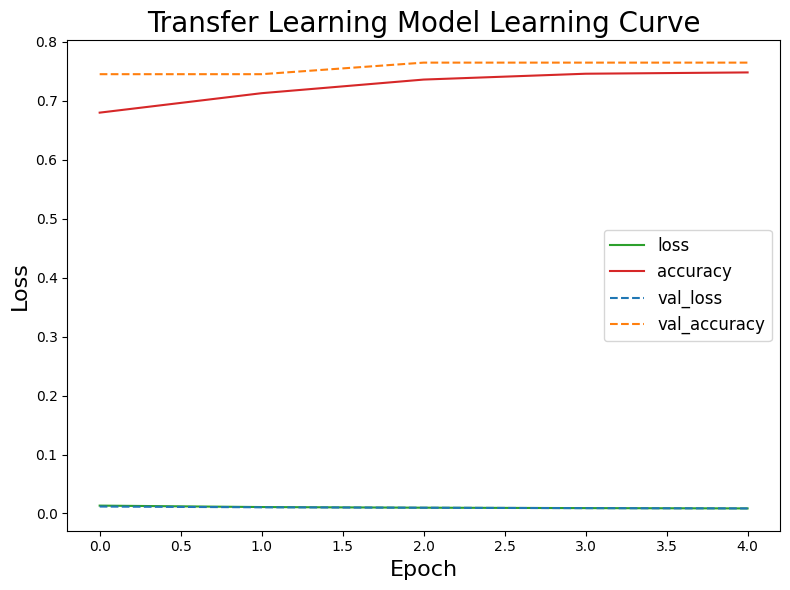

In [47]:
loss, acc = history2.history['loss'], history2.history['accuracy']
val_loss, val_acc = history2.history['val_loss'], history2.history['val_accuracy']
plt.figure(22, figsize=(8,6))
plt.clf()
plt.plot(loss, label='loss', color = 'C2')
plt.plot(acc, label='accuracy', color ='C3')
plt.plot(val_loss, ls='--', label='val_loss', color = 'C0')
plt.plot(val_acc, ls='--', label='val_accuracy', color ='C1')
# plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch', fontsize = 16)
plt.ylabel('Loss', fontsize = 16)
plt.title('Transfer Learning Model Learning Curve', fontsize = 20)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('model_latest_loss_curve.png')



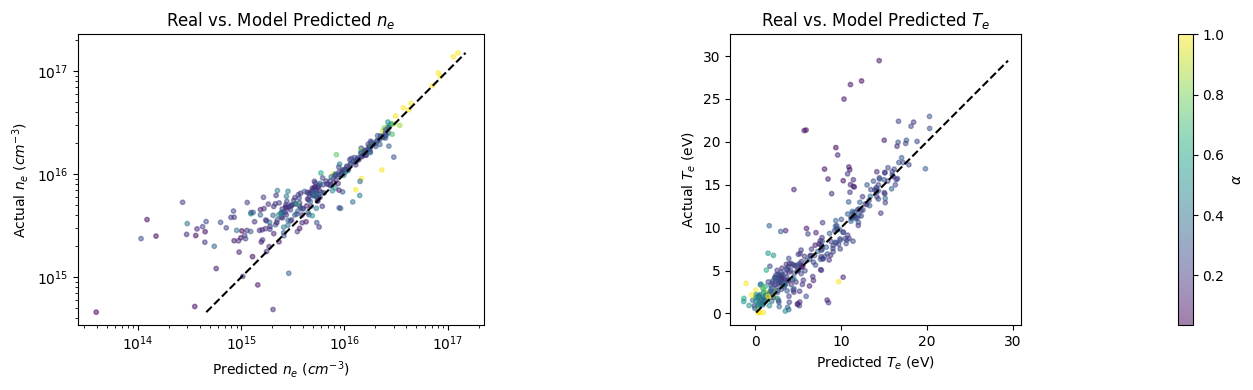

In [48]:
# Predictions (already-scaled -> back to physical units)
predicted_scaled = emodel.predict(X_test, verbose=0)
predict = y_scaler.inverse_transform(predicted_scaled)
truth = y_scaler.inverse_transform(y_test)

# alpha is the 3rd target in this model (n_e, T_e, alpha)
color = np.clip(truth[:, 2], 0, 1)

# Guard log plot against non-positive values
ne_pred = predict[:, 0]
ne_true = truth[:, 0]
mask_ne = np.isfinite(ne_pred) & np.isfinite(ne_true) & (ne_pred > 0) & (ne_true > 0)

te_pred = predict[:, 1]
te_true = truth[:, 1]
mask_te = np.isfinite(te_pred) & np.isfinite(te_true)

plt.figure(figsize=(14, 4))
plt.clf()

# Density plot
plt.subplot(121)
plt.xscale("log")
plt.yscale("log")
plt.scatter(ne_pred[mask_ne], ne_true[mask_ne], c=color[mask_ne], cmap="viridis", alpha=0.5, s=10)
mn, mx = ne_true[mask_ne].min(), ne_true[mask_ne].max()
plt.plot([mn, mx], [mn, mx], ls="--", c="k")
plt.xlabel("Predicted $n_e$ ($cm^{-3}$)")
plt.ylabel("Actual $n_e$ ($cm^{-3}$)")
plt.title("Real vs. Model Predicted $n_e$")
plt.axis("square")


# Temperature plot
plt.subplot(122)
sc2 = plt.scatter(te_pred[mask_te], te_true[mask_te], c=color[mask_te], cmap="viridis", alpha=0.5, s=10)
mn, mx = te_true[mask_te].min(), te_true[mask_te].max()
plt.plot([mn, mx], [mn, mx], ls="--", c="k", label="calibration")
plt.xlabel("Predicted $T_e$ (eV)")
plt.ylabel("Actual $T_e$ (eV)")
plt.title("Real vs. Model Predicted $T_e$")
cbar = plt.colorbar(sc2)
cbar.set_label(r"$\alpha$")
plt.axis("square")

plt.tight_layout()
plt.show()

**Script for Manual Fitting, includes functions for plotting 2x3 plots of spectra, and plotting 5 manual fits**

(1350,) (1350,)
Guesses:  700000000000000.0 1 / cm3 3.5 eV
True n_e and T_e for 1079 are:  4.381987908249905 3.598651270340599
alpha is:  0.11397995271476652


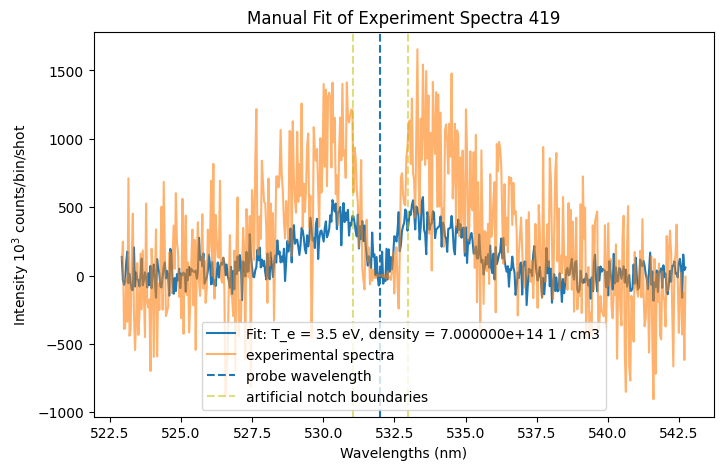

In [49]:
#manual fitting procedure, to compare with model performance, and to create figures for the report.
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from lmfit import Parameters
from plasmapy.diagnostics import thomson
from scipy.signal import convolve

#plt.rcParams.update({'font.size': 20})
n_e = np.load('ne.npy')
T_e = np.load('Te.npy')
spectra = np.load('TS_spectra.npy')
wavelengths = np.load('wavelength.npy')
print(n_e.shape, T_e.shape)

probe_wavelength = 532 * u.nm
probe_vec = np.array([1, 0, 0])
scattering_angle = np.deg2rad(90)
scatter_vec = np.array([np.cos(scattering_angle), np.sin(scattering_angle), 0])

wavelength_units = wavelengths * u.nm

def plot_subplots(x, y):
    fig, axes = plt.subplots(2, 3, figsize=(20, 8))
    axes = axes.flatten()

    for ax_idx in range(6):
        ax = axes[ax_idx]
        ax.plot(x, y[ax_idx], linewidth=1, label=f'spectra {ax_idx+1}', color = 'y')
        ax.set_title(f"Spectra {ax_idx}")
        ax.set_xlabel("wavelength (nm)")
        ax.set_ylabel("Intensity 10$^3$ counts/bin/shot")
        ax.legend(fontsize=6)
def plot_manual_fits(x, y, n, T, Skw_scaled, scale_factors, indices):
    fig, axes = plt.subplots(2, 3, figsize=(20, 8))
    axes = axes.flatten()
    i = 0
    for ax_idx in range(5):
        ax = axes[ax_idx]
        ax.plot(x, Skw_scaled[i]*scale_factors[i], label = f'Fit: T_e = {T[i]}, density = {n[i]:e}', alpha = 1)
        spectra_idx = indices[i]
        ax.plot(x, y[spectra_idx], label = 'experimental spectra', alpha = 0.6)
        ax.set_title(f"Manual Fit of Spectra {indices[i]}")
        ax.set_xlabel("wavelength (nm)")
        ax.set_ylabel("Intensity 10$^3$ counts/bin/shot")
        ax.axvline(532, linestyle = '--', label = 'probe wavelength', alpha = 1)
        ax.axvline(532-0.48*(2), linestyle = '--', alpha = 0.5, color = 'y')
        ax.axvline(532+0.48*(2), linestyle = '--', label = 'artificial notch boundaries', alpha = 0.5, color = 'y')
        ax.legend(fontsize=6)
        i+=1
    plt.tight_layout()
    plt.show()

def instrument_function(k):
    xpix = np.arange(len(k))
    center = len(wavelengths) // 2
    sigma = 2.18
    lineshape = np.exp(-((xpix - center) ** 2) / (2 * .124**2))
    lineshape /= np.sum(lineshape)
    return lineshape
def calculate_mae(true_value, predicted_value):
    return abs(true_value - predicted_value)

#manual guess/check, the random set of spectra were non-collective,since most of the experiment is non-collective
n = 7e14 * u.cm**-3
T = 3.5 * u.eV
T_i = np.array([1]) * u.eV


print("Guesses: ", n, T)

alpha, skw = thomson.spectral_density(
    wavelength_units,
    probe_wavelength,
    n,
    T_e=T,
    T_i=T_i,
    probe_vec=probe_vec,
    scatter_vec=scatter_vec,
)

Skw = np.array(skw.value)

manual_inst_func = instrument_function(wavelengths)
Skw_conv = convolve(Skw, manual_inst_func, mode="same") #detectors have uncertainty, convolve skw with a gaussian (inst. func) to mimic this spread of uncertainty

notch = 1 - np.exp(-((wavelengths - 532.0) ** 2) / (2 * 0.48**2))
Skw_notched = Skw_conv * notch

Skw_normalized = Skw_notched / np.nanmax(Skw_notched)
Skw_scaled = Skw_normalized * np.nanmax(spectra[1079]*notch) #first normalize, then sclale it by intensity

#idxs = np.random.choice(1350, size=5, replace=False)
#print(idxs)
#ran once, used those numbers for every other run: 759, 43, 1079, 604, and 420.
idxs = [759, 43, 1079, 604, 420]

print("True n_e and T_e for 1079 are: ", n_e[1079]/10e14, T_e[1079])
print("alpha is: ", alpha)

"""
plt.figure(figsize = (8,5))
plt.plot(wavelengths, Skw_scaled*0.85, label = f'Fit: T_e = {T}, density = {n:e}', alpha = 1)
plt.plot(wavelengths, spectra[1079], label = 'experimental spectra', alpha = 0.6)
plt.ylabel('Intensity 10$^3$ counts/bin/shot')
plt.xlabel('Wavelengths (nm)')
plt.axvline(532, linestyle = '--', label = 'probe wavelength', alpha = 1)
plt.axvline(532-0.48*(2), linestyle = '--', alpha = 0.5, color = 'y')
plt.axvline(532+0.48*(2), linestyle = '--', label = 'artificial notch boundaries', alpha = 0.5, color = 'y')
plt.title('Manual Fit of Experiment Spectra 1079')
plt.legend()
plt.show()
"""

#manual parameters
manual_T_e = [13,3.75,3.5,20, 4.5]
manual_n_e = [5e15,9e14,7e14, 4.5e15, 6e14]

scale_factors=[0.85, 0.85, 0.7, 0.85, 0.85]

maes_n_e = []
maes_T_e = []
for i in range(0,5):
    index = idxs[i]
    maes_n_e.append(calculate_mae(n_e[index], manual_n_e[i]))
    maes_T_e.append(calculate_mae(T_e[index], manual_T_e[i]))

maes_n_e = np.array(maes_n_e)
maes_T_e = np.array(maes_T_e)

skws = []
alphas = []
for i in range(0,5):
    alpha, skw = thomson.spectral_density(
        wavelength_units,
        probe_wavelength,
        manual_n_e[i]*u.cm**-3,
        T_e=manual_T_e[i]*u.eV,
        T_i=T_i,
        probe_vec=probe_vec,
        scatter_vec=scatter_vec,
    )
    Skw = np.array(skw.value)

    manual_inst_func = instrument_function(wavelengths)
    Skw_conv = convolve(Skw, manual_inst_func, mode="same") #detectors have uncertainty, convolve skw with a gaussian (inst. func) to mimic this spread of uncertainty

    notch = 1 - np.exp(-((wavelengths - 532.0) ** 2) / (2 * 0.48**2))
    Skw_notched = Skw_conv * notch

    Skw_normalized = Skw_notched / np.nanmax(Skw_notched)
    Skw_scaled = Skw_normalized * np.nanmax(spectra[idxs[i]]*notch)

    skws.append(Skw_scaled)
    alphas.append(alpha)
alphas = np.array(alphas)
#plot_manual_fits(wavelengths, spectra, manual_n_e, manual_T_e, skws, scale_factors, idxs)
"""
all_alphas = []
all_skws = []

n_e_units = n_e * u.cm**-3
T_e_units = T_e * u.eV
for i in range(len(spectra)):
    alpha, skw = thomson.spectral_density(
        wavelength_units,
        probe_wavelength,
        n_e_units,
        T_e=T_e_units,
        T_i=T_i,
        probe_vec=probe_vec,
        scatter_vec=scatter_vec,
    )

    all_alphas.append(alpha)
    all_skws.append(skw)
all_alphas=np.array(all_alphas)
all_skws=np.array(all_skws)

plt.hist(all_alphas, color = 'red', label = f"mean = {alphas.mean()} , std = {alphas.std()}")
plt.show()
#guessing for
n = 6e14 * u.cm**-3
T = 4.5 * u.eV

print(n, T)

alpha, skw = thomson.spectral_density(
    wavelength_units,
    probe_wavelength,
    n,
    T_e=T,
    T_i=T_i,
    probe_vec=probe_vec,
    scatter_vec=scatter_vec,
)

Skw = np.array(skw.value)

manual_inst_func = instrument_function(wavelengths)
Skw_conv = convolve(Skw, manual_inst_func, mode="same") #detectors have uncertainty, convolve skw with a gaussian (inst. func) to mimic this spread of uncertainty

notch = 1 - np.exp(-((wavelengths - 532.0) ** 2) / (2 * 0.48**2))
Skw_notched = Skw_conv * notch

Skw_normalized = Skw_notched / np.nanmax(Skw_notched)
Skw_scaled = Skw_normalized * np.nanmax(spectra[0]*notch) #first normalize, then sclale it by intensity

"""
mean = 0
std_dev = 10 ** 2.5
noise = np.random.normal(mean, std_dev, wavelengths.size)
Skw_scaled += noise


idxs = np.random.choice(1350, size=5, replace=False)
#print(idxs)
#not ran in notebook, so it choose =759, 43, 1079, 421, and 604 on prev run.
#print(n_e[420]/10e14, T_e[420])

plt.figure(figsize = (8,5))
plt.plot(wavelengths, Skw_scaled*(4/15), label = f'Fit: T_e = {T}, density = {n:e}', alpha = 1)
plt.plot(wavelengths, spectra[420]*notch, label = 'experimental spectra', alpha = 0.6)
plt.ylabel('Intensity 10$^3$ counts/bin/shot')
plt.xlabel('Wavelengths (nm)')
plt.axvline(532, linestyle = '--', label = 'probe wavelength', alpha = 1)
plt.axvline(532-0.48*(2), linestyle = '--', alpha = 0.5, color = 'y')
plt.axvline(532+0.48*(2), linestyle = '--', label = 'artificial notch boundaries', alpha = 0.5, color = 'y')
plt.title('Manual Fit of Experiment Spectra 419')
plt.legend()
plt.show()


**RandomForest Model as a Comparison to Neural Network**

In [50]:
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
)

import warnings
warnings.filterwarnings("ignore")

In [51]:
X  = np.load('TS_spectra.npy')
N_e = np.log10(np.load('ne.npy'))
T_e = np.load('Te.npy')

Y = np.column_stack([N_e, T_e])
target_names = ["N_e", "T_e"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(
    n_estimators = 5,
    max_depth=10,
    oob_score=True,
    random_state=42,
)

rf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",5
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [52]:
Y_pred_train = rf.predict(X_train)
Y_pred_test  = rf.predict(X_test)

target_names=["n_e", "T_e"]
n_targets = Y_train.shape[1]
for i, name in enumerate(target_names):
        tr_r2   = r2_score(Y_train[:, i], Y_pred_train[:, i])
        te_r2   = r2_score(Y_test[:, i],  Y_pred_test[:, i])

        print(name)
        print(f"R², train and test are: {tr_r2:.2f} and {te_r2:.2f} respectively")

n_e
R², train and test are: 0.86 and 0.69 respectively
T_e
R², train and test are: 0.89 and 0.45 respectively
